<div dir="rtl">

# تعریف مسئله و متغیر هدف

در این بخش، هدف اصلی مشخص کردن دقیق مسئله‌ی پیش‌بینی است. از آن‌جا که مجموعه‌داده شامل آگهی‌های مختلف فروش، رهن و اجاره است، لازم است پیش از آموزش مدل تعیین شود که مدل قرار است دقیقاً چه مقدار مالی‌ای را پیش‌بینی کند.

برای این منظور، ابتدا انواع معامله‌های موجود در داده بررسی می‌شوند و سپس برای هر نوع معامله، ستون مناسب به‌عنوان متغیر هدف (`Target`) انتخاب خواهد شد.

مواردی که در این مرحله بررسی می‌شوند شامل موارد زیر هستند:

1. تعیین نوع مسئله‌ی پیش‌بینی برای آگهی‌های فروش و اجاره.
2. مشخص کردن ستون مناسب قیمت برای آگهی‌های فروش.
3. مشخص کردن مقدار مالی مناسب برای آگهی‌های رهن و اجاره.
4. بررسی امکان استفاده از یک مدل مشترک یا مدل‌های جداگانه برای انواع معامله.
5. بررسی تعداد داده‌های دارای Target معتبر برای هر گروه.
6. مشخص کردن داده‌هایی که به دلیل نداشتن Target معتبر، قابل استفاده در مدل‌سازی نیستند.

هدف این مرحله، رسیدن به یک تعریف شفاف و قابل دفاع از متغیر هدف است تا در مراحل بعدی، انتخاب Featureها، تقسیم داده و آموزش مدل بر اساس همین تعریف انجام شود.

</div>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_parquet("../data/Divar_cleaned.parquet")


In [3]:
valid_transaction_types = [
    "residential-sell",
    "commercial-sell",
    "residential-rent",
    "commercial-rent"
]

model_df = df[df["cat2_slug"].isin(valid_transaction_types)].copy()

print("Rows before filtering:", len(df))
print("Rows after filtering:", len(model_df))

print("\nSelected transaction types:")
print(model_df["cat2_slug"].value_counts())

Rows before filtering: 999997
Rows after filtering: 950691

Selected transaction types:
cat2_slug
residential-sell    558707
residential-rent    276558
commercial-rent      76565
commercial-sell      38861
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

### بررسی آگهی‌های اجاره کوتاه‌مدت

در این مرحله، آگهی‌های دسته‌ی `temporary-rent` به‌صورت جداگانه بررسی شدند تا مشخص شود آیا می‌توان برای آن‌ها نیز متغیر هدف مشترک `unified_price` را تعریف کرد یا خیر.

تعداد کل آگهی‌های اجاره کوتاه‌مدت برابر با **29,903** ردیف بود.

بررسی ستون‌های مالی نشان داد:

- تنها **5** ردیف دارای `price_value` بودند.
- تنها **3** ردیف دارای `credit_value` بودند.
- تنها **3** ردیف دارای `rent_value` بودند.
- ستون‌های `transformable_credit`، `transformed_credit`، `transformable_rent` و `transformed_rent` برای تمام این دسته فاقد مقدار بودند.
- ستون `rent_type` نیز تنها برای **2** ردیف مقدار داشت.
- `inferred_full_credit` نیز فقط برای **2** ردیف قابل تشخیص بود.

بنابراین تقریباً تمام آگهی‌های `temporary-rent` فاقد اطلاعات مالی لازم برای ساخت `unified_price` هستند.

در نتیجه، با وجود اینکه اجاره کوتاه‌مدت از نظر مفهومی جزو معاملات اجاره محسوب می‌شود، در این دیتاست امکان تعریف یک Target مالی قابل اتکا برای آن وجود ندارد. به همین دلیل، این دسته از داده‌های مورد استفاده برای مدل پیش‌بینی حذف می‌شود.

همچنین دسته‌ی `real-estate-services` نیز به دلیل اینکه مربوط به خدمات حوزه املاک است و نه معامله مستقیم یک ملک، وارد مدل نخواهد شد.

در نتیجه، انواع معامله‌ی مورد استفاده در مدل عبارت‌اند از:

- `residential-sell`
- `commercial-sell`
- `residential-rent`
- `commercial-rent`

</div>

In [4]:

is_sell = model_df["cat2_slug"].str.contains("sell", na=False)

is_full_credit = (
    (model_df["inferred_full_credit"] == True)
    .fillna(False)
)

conditions = [
    is_sell,
    is_full_credit
]

choices = [
    model_df["price_value"],
    model_df["transformable_credit"]
]

model_df["unified_price"] = np.select(
    conditions,
    choices,
    default=model_df["transformed_credit"]
)

# Zero cannot be used as a valid target
model_df["unified_price"] = model_df["unified_price"].replace(0, np.nan)

In [5]:
valid_target = model_df["unified_price"].notna()

print("Total modeling rows:", len(model_df))
print("Valid targets:", valid_target.sum())
print("Missing targets:", (~valid_target).sum())
print(
    "Target coverage:",
    round(valid_target.mean() * 100, 2),
    "%"
)

print("\nValid targets by transaction type:")
print(
    model_df.loc[valid_target, "cat2_slug"]
    .value_counts()
)

Total modeling rows: 950691
Valid targets: 680999
Missing targets: 269692
Target coverage: 71.63 %

Valid targets by transaction type:
cat2_slug
residential-sell    533260
residential-rent    104051
commercial-sell      31929
commercial-rent      11759
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

### تعریف نهایی مسئله و متغیر هدف

در این پروژه یک مدل رگرسیون مشترک برای پیش‌بینی ارزش مالی آگهی‌های املاک در نظر گرفته شد.

چهار نوع معامله در داده‌های مدل نگه داشته شدند:

- فروش مسکونی
- فروش تجاری
- اجاره مسکونی
- اجاره تجاری

دسته‌ی `real-estate-services` به دلیل مربوط بودن به خدمات املاک و دسته‌ی `temporary-rent` به دلیل نبود اطلاعات مالی کافی برای تعریف متغیر هدف، از داده‌های مدل حذف شدند.

متغیر هدف مدل با نام `unified_price` تعریف شد تا انواع مختلف معاملات دارای یک Target عددی مشترک باشند.

منطق ساخت متغیر هدف به شکل زیر است:

- در آگهی‌های فروش از `price_value` استفاده می‌شود.
- در آگهی‌های رهن کامل، که با `inferred_full_credit` تشخیص داده می‌شوند، از `transformable_credit` استفاده می‌شود.
- در سایر آگهی‌های اجاره از `transformed_credit` استفاده می‌شود.
- مقادیر صفر به‌عنوان Target معتبر در نظر گرفته نمی‌شوند.

همچنین نوع معامله (`cat2_slug`) در مراحل بعدی به‌عنوان یکی از ویژگی‌های ورودی مدل استفاده خواهد شد تا مدل بتواند تفاوت میان انواع معاملات را تشخیص دهد.

</div>

<div dir="rtl">

# تسک ۲ — ساخت دیتاست نهایی مدل و بررسی کیفیت Target

در این مرحله، متغیر هدف نهایی برای مدل ساخته و کیفیت آن بررسی می‌شود.

اهداف این بخش:

- بررسی Targetهای گمشده
- بازیابی Targetهایی که از اطلاعات مالی موجود قابل محاسبه هستند
- ساخت Target نهایی برای فروش و اجاره
- بررسی مقادیر غیرعادی و Outlierها
- ساخت دیتاست نهایی مخصوص مدل‌سازی
- حفظ داده‌های اصلی بدون تغییر

در این مرحله Outlierها شناسایی می‌شوند، اما برای جلوگیری از نشت اطلاعات، مرزهای نهایی Capping بعد از تقسیم Train / Validation / Test و فقط بر اساس Train محاسبه خواهند شد.

</div>

In [6]:
missing_target_df = model_df[
    model_df["unified_price"].isna()
].copy()

print("Total missing targets:", len(missing_target_df))

print("\nMissing targets by transaction type:")
print(missing_target_df["cat2_slug"].value_counts())

Total missing targets: 269692

Missing targets by transaction type:
cat2_slug
residential-rent    172507
commercial-rent      64806
residential-sell     25447
commercial-sell       6932
Name: count, dtype: int64[pyarrow]


In [7]:
check_cols = [
    "price_value",
    "credit_value",
    "rent_value",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",
    "rent_type",
    "rent_credit_transform",
    "inferred_full_credit"
]

for category in missing_target_df["cat2_slug"].dropna().unique():

    subset = missing_target_df[
        missing_target_df["cat2_slug"] == category
    ]

    print("\n" + "=" * 70)
    print("Category:", category)
    print("Rows:", len(subset))

    for col in check_cols:
        print(
            f"{col:25s} -> "
            f"{subset[col].notna().sum():,} non-null"
        )


Category: residential-rent
Rows: 172507
price_value               -> 6 non-null
credit_value              -> 172,033 non-null
rent_value                -> 171,269 non-null
transformable_credit      -> 172,033 non-null
transformed_credit        -> 19 non-null
transformable_rent        -> 171,268 non-null
transformed_rent          -> 19 non-null
rent_type                 -> 48,438 non-null
rent_credit_transform     -> 172,483 non-null
inferred_full_credit      -> 47,254 non-null

Category: commercial-rent
Rows: 64806
price_value               -> 34 non-null
credit_value              -> 64,240 non-null
rent_value                -> 64,231 non-null
transformable_credit      -> 64,240 non-null
transformed_credit        -> 17 non-null
transformable_rent        -> 64,227 non-null
transformed_rent          -> 17 non-null
rent_type                 -> 14,687 non-null
rent_credit_transform     -> 64,691 non-null
inferred_full_credit      -> 14,248 non-null

Category: residential-sell
Rows: 25447


In [8]:
conversion_df = model_df[
    model_df["credit_value"].notna()
    & model_df["rent_value"].notna()
    & model_df["transformed_credit"].notna()
    & model_df["transformed_rent"].notna()
].copy()

denominator = (
    conversion_df["rent_value"]
    - conversion_df["transformed_rent"]
)

valid_conversion = denominator != 0

conversion_df = conversion_df.loc[
    valid_conversion
].copy()

conversion_df["conversion_rate"] = (
    (
        conversion_df["transformed_credit"]
        - conversion_df["credit_value"]
    )
    /
    (
        conversion_df["rent_value"]
        - conversion_df["transformed_rent"]
    )
)

valid_rates = conversion_df.loc[
    (conversion_df["conversion_rate"] > 0)
    & np.isfinite(conversion_df["conversion_rate"]),
    "conversion_rate"
]

conversion_rate = valid_rates.median()

print("Valid conversion rows:", len(valid_rates))
print("Median conversion rate:", conversion_rate)

Valid conversion rows: 72409
Median conversion rate: 33.333333333333336


In [9]:
model_ready_df = model_df.copy()

is_sell = model_ready_df["cat2_slug"].str.contains(
    "sell",
    na=False
)

is_rent = model_ready_df["cat2_slug"].str.contains(
    "rent",
    na=False
)

model_ready_df["unified_price_final"] = np.nan


# Sale
valid_sell = (
    is_sell
    & model_ready_df["price_value"].notna()
    & (model_ready_df["price_value"] > 0)
)

model_ready_df.loc[
    valid_sell,
    "unified_price_final"
] = model_ready_df.loc[
    valid_sell,
    "price_value"
]


# Rent / Full Credit
valid_rent = (
    is_rent
    & model_ready_df["credit_value"].notna()
    & model_ready_df["rent_value"].notna()
)

model_ready_df.loc[
    valid_rent,
    "unified_price_final"
] = (
    model_ready_df.loc[
        valid_rent,
        "credit_value"
    ]
    +
    model_ready_df.loc[
        valid_rent,
        "rent_value"
    ] * conversion_rate
)

In [10]:
valid_final_target = (
    model_ready_df["unified_price_final"].notna()
)

print("Total rows:", len(model_ready_df))

print(
    "Valid final targets:",
    valid_final_target.sum()
)

print(
    "Missing final targets:",
    (~valid_final_target).sum()
)

print(
    "Coverage:",
    round(valid_final_target.mean() * 100, 2),
    "%"
)

print("\nValid targets by transaction type:")

print(
    model_ready_df.loc[
        valid_final_target,
        "cat2_slug"
    ].value_counts()
)

Total rows: 950691
Valid final targets: 916369
Missing final targets: 34322
Coverage: 96.39 %

Valid targets by transaction type:
cat2_slug
residential-sell    533260
residential-rent    275264
commercial-rent      75916
commercial-sell      31929
Name: count, dtype: int64[pyarrow]


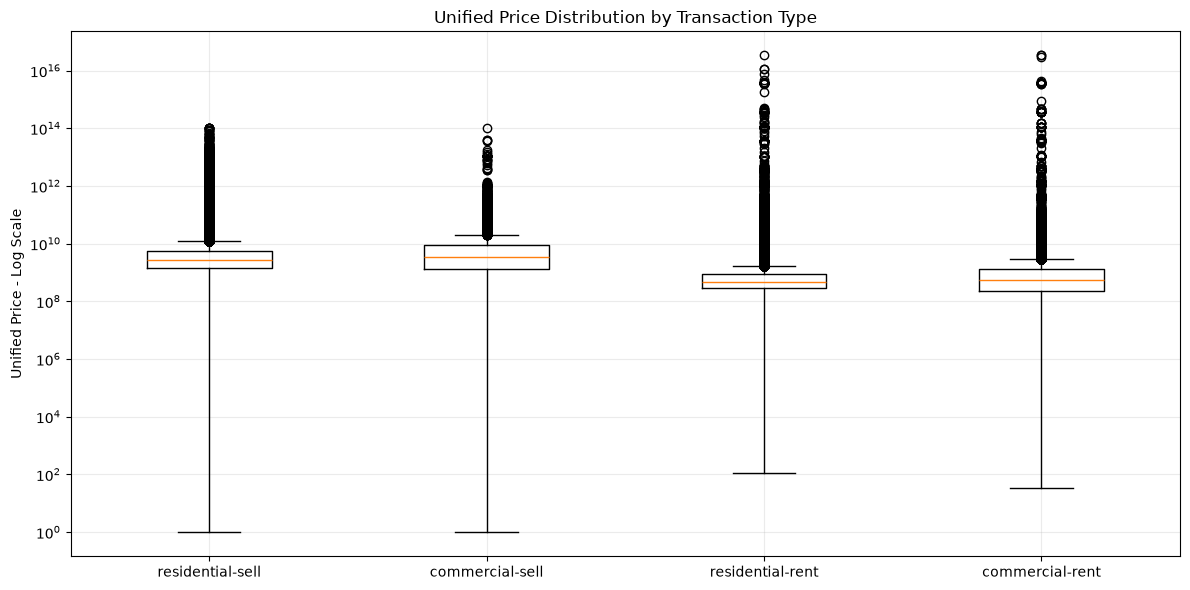

In [11]:
import matplotlib.pyplot as plt

box_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

category_order = [
    "residential-sell",
    "commercial-sell",
    "residential-rent",
    "commercial-rent"
]

data = []

for cat in category_order:

    values = pd.to_numeric(
        box_df.loc[
            box_df["cat2_slug"] == cat,
            "unified_price_final"
        ],
        errors="coerce"
    ).dropna().astype(float).to_numpy()

    data.append(values)

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    tick_labels=category_order,
    showfliers=True
)

plt.yscale("log")

plt.title(
    "Unified Price Distribution by Transaction Type"
)

plt.ylabel(
    "Unified Price - Log Scale"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [12]:
outlier_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

outlier_df["log_target"] = np.log1p(
    outlier_df["unified_price_final"]
)

outlier_df["extreme_outlier"] = False

for cat in outlier_df["cat2_slug"].unique():

    mask = outlier_df["cat2_slug"] == cat

    values = outlier_df.loc[
        mask,
        "log_target"
    ]

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr

    outlier_df.loc[
        mask
        & (
            (outlier_df["log_target"] < lower)
            | (outlier_df["log_target"] > upper)
        ),
        "extreme_outlier"
    ] = True


print(
    "Total valid targets:",
    len(outlier_df)
)

print(
    "Extreme outliers:",
    outlier_df["extreme_outlier"].sum()
)

print(
    "\nExtreme outliers by category:"
)

print(
    outlier_df.loc[
        outlier_df["extreme_outlier"],
        "cat2_slug"
    ].value_counts()
)

Total valid targets: 916369
Extreme outliers: 16600

Extreme outliers by category:
cat2_slug
residential-sell    11991
residential-rent     2514
commercial-sell      1632
commercial-rent       463
Name: count, dtype: int64[pyarrow]


In [13]:
model_ready_df["extreme_outlier"] = False

model_ready_df.loc[
    outlier_df.index,
    "extreme_outlier"
] = outlier_df["extreme_outlier"]

print(
    "Extreme outliers:",
    model_ready_df["extreme_outlier"].sum()
)

Extreme outliers: 16600


In [14]:
before = len(model_ready_df)

model_ready_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

removed = before - len(model_ready_df)

print(
    "Rows before target cleaning:",
    before
)

print(
    "Final modeling rows:",
    len(model_ready_df)
)

print(
    "Removed missing targets:",
    removed
)

print(
    "Missing targets:",
    model_ready_df[
        "unified_price_final"
    ].isna().sum()
)

print(
    "Extreme outliers flagged:",
    model_ready_df[
        "extreme_outlier"
    ].sum()
)

print(
    "\nFinal rows by transaction type:"
)

print(
    model_ready_df[
        "cat2_slug"
    ].value_counts()
)

Rows before target cleaning: 950691
Final modeling rows: 916369
Removed missing targets: 34322
Missing targets: 0
Extreme outliers flagged: 16600

Final rows by transaction type:
cat2_slug
residential-sell    533260
residential-rent    275264
commercial-rent      75916
commercial-sell      31929
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

# جمع‌بندی نهایی تسک ۲ — ساخت و اعتبارسنجی متغیر هدف

هدف این مرحله، ساخت یک متغیر هدف عددی، قابل مقایسه و قابل استفاده برای آموزش مدل رگرسیون بود؛ به‌گونه‌ای که تفاوت ساختاری میان معاملات فروش، رهن کامل و رهن‌واجاره باعث از دست رفتن بخش بزرگی از داده‌ها نشود.

---

## ۱. مشکل تعریف اولیه‌ی Target

در تعریف اولیه، برای فروش از `price_value` و برای بخش اجاره عمدتاً از ستون‌های تبدیل‌شده مانند `transformed_credit` استفاده شده بود.

این تعریف باعث شد از مجموع **950,691** رکورد انتخاب‌شده، تنها **680,999** رکورد دارای Target معتبر باشند و پوشش Target برابر با **71.63٪** شود.

بررسی دقیق‌تر نشان داد بخش قابل توجهی از Missing Targetها واقعاً فاقد اطلاعات مالی نبودند. برای مثال، تعداد زیادی از آگهی‌های اجاره دارای مقادیر معتبر `credit_value` و `rent_value` بودند، اما چون ستون `transformed_credit` تنها در بخشی از داده‌ها مقدار داشت، Target آن‌ها به اشتباه Missing شده بود.

بنابراین Missing بودن `transformed_credit` لزوماً به معنای نبود اطلاعات مالی قابل استفاده نبود.

---

## ۲. تعریف Target برای آگهی‌های فروش

برای معاملات فروش، متغیر هدف مستقیماً از:

`price_value`

گرفته شد.

این انتخاب از نظر مفهومی مستقیم‌ترین تعریف ممکن است، زیرا `price_value` همان مبلغ اعلام‌شده برای فروش ملک است و نیاز به هیچ تبدیل مالی دیگری ندارد.

فقط مقادیر مثبت به‌عنوان Target معتبر پذیرفته شدند و مقادیر صفر یا Missing وارد داده‌ی آموزشی نشدند.

---

## ۳. یکپارچه‌سازی رهن و اجاره

آگهی‌های اجاره می‌توانند شامل دو جزء مالی باشند:

- مبلغ رهن یا ودیعه (`credit_value`)
- مبلغ اجاره (`rent_value`)

استفاده مستقیم از این دو مقدار به‌عنوان دو Target مستقل با هدف این پروژه سازگار نبود، زیرا مدل باید یک خروجی عددی واحد پیش‌بینی کند.

به همین دلیل، برای معاملات اجاره یک **ارزش معادل رهن** تعریف شد:

`Equivalent Credit = credit_value + rent_value × conversion_rate`

در نتیجه، تمام حالت‌های اجاره به یک مقیاس مالی مشترک تبدیل شدند.

این تعریف همچنین رهن کامل را به‌صورت طبیعی پوشش می‌دهد؛ زیرا در رهن کامل مقدار اجاره برابر صفر است و رابطه به شکل زیر ساده می‌شود:

`Equivalent Credit = credit_value`

بنابراین نیازی به تعریف Target جداگانه برای رهن کامل وجود ندارد.

---

## ۴. دلیل استفاده از نرخ تبدیل استخراج‌شده از خود دیتاست

به‌جای انتخاب یک نرخ تبدیل ثابت و قراردادی از بیرون دیتاست، نرخ تبدیل با استفاده از رکوردهایی استخراج شد که در آن‌ها مقادیر اولیه و مقادیر تبدیل‌شده‌ی رهن و اجاره به‌طور همزمان وجود داشتند.

برای هر رکورد معتبر، نرخ تبدیل از رابطه‌ی میان:

`credit_value`،
`rent_value`،
`transformed_credit`
و
`transformed_rent`

محاسبه شد.

سپس **میانه (Median)** نرخ‌های معتبر به‌عنوان نرخ تبدیل نهایی انتخاب شد.

استفاده از Median نسبت به Mean در این مسئله مناسب‌تر است، زیرا Median در برابر مقادیر بسیار بزرگ، داده‌های اشتباه و توزیع‌های دارای چولگی، مقاومت بیشتری دارد و کمتر تحت تأثیر Outlierها قرار می‌گیرد.

---

## ۵. Target نهایی

پس از اصلاح تعریف مسئله، Target نهایی با نام:

`unified_price_final`

ساخته شد.

منطق آن به شکل زیر است:

**فروش:**

`unified_price_final = price_value`

**رهن و اجاره:**

`unified_price_final = credit_value + rent_value × conversion_rate`

در نتیجه، انواع مختلف معامله به یک خروجی عددی واحد تبدیل شدند، در حالی که نوع معامله همچنان از طریق Featureهایی مانند `cat2_slug` برای مدل قابل تشخیص خواهد بود.

---

## ۶. نتیجه‌ی بازیابی Missing Targetها

پس از بازتعریف Target:

- تعداد کل رکوردهای مورد بررسی: **950,691**
- Target معتبر: **916,369**
- Target غیرقابل بازیابی: **34,322**
- پوشش Target: **96.39٪**

بنابراین پوشش Target از:

**71.63٪ → 96.39٪**

افزایش یافت.

این افزایش بدون تخمین مصنوعی قیمت با Mean، Median، KNN یا مدل‌های دیگر انجام شد؛ بلکه تنها از اطلاعات مالی واقعی موجود در همان رکوردها استفاده شد.

این موضوع اهمیت دارد، زیرا پر کردن Target با مقادیر تخمینی می‌تواند Label Noise ایجاد کند و مدل را مجبور کند به مقادیری آموزش ببیند که Ground Truth واقعی نیستند.

---

## ۷. چرا Targetهای باقی‌مانده Impute نشدند؟

برای **34,322** رکورد باقی‌مانده اطلاعات کافی برای محاسبه‌ی یک Target قابل دفاع وجود نداشت.

در چنین شرایطی، Imputation متغیر هدف با روش‌هایی مانند میانگین، میانه یا مدل پیش‌بینی مناسب نیست؛ زیرا Target همان متغیری است که مدل قرار است یاد بگیرد.

ساختن Target مصنوعی می‌تواند:

- خطای برچسب ایجاد کند،
- رابطه‌ی واقعی Featureها و Target را تحریف کند،
- معیارهای ارزیابی را بیش از حد خوش‌بینانه نشان دهد،
- و باعث آموزش مدل روی مقادیر غیرواقعی شود.

بنابراین این رکوردها از دیتاست Modeling کنار گذاشته شدند، ولی داده‌ی اصلی بدون تغییر باقی ماند.

---

## ۸. بررسی Outlierها

توزیع `unified_price_final` با Box Plot و آمار توصیفی بررسی شد.

به دلیل ماهیت قیمت املاک، توزیع Target دارای چولگی شدید و دنباله‌ی بلند بود. در چنین داده‌ای، بالا بودن قیمت به‌تنهایی دلیل کافی برای حذف یک رکورد نیست؛ زیرا املاک گران‌قیمت واقعی نیز در بازار وجود دارند.

برای شناسایی فقط مقادیر بسیار شدید، ابتدا تبدیل لگاریتمی انجام شد:

`log_target = log(1 + unified_price_final)`

سپس Outlierهای شدید به‌صورت جداگانه برای هر نوع معامله و با معیار محافظه‌کارانه‌ی:

`Q1 - 3 × IQR`

و

`Q3 + 3 × IQR`

شناسایی شدند.

استفاده از ضریب **3×IQR** به‌جای **1.5×IQR** باعث می‌شود تنها نقاط بسیار دورافتاده علامت‌گذاری شوند و تعداد زیادی از املاک گران یا ارزان ولی واقعی، به اشتباه Outlier محسوب نشوند.

---

## ۹. نتیجه‌ی بررسی Outlierها

از مجموع **916,369** Target معتبر:

- **16,600** رکورد به‌عنوان Extreme Outlier شناسایی شدند.
- این مقدار تنها حدود **1.81٪** داده‌های معتبر است.

در این مرحله این رکوردها حذف نشدند و تنها با Feature:

`extreme_outlier`

علامت‌گذاری شدند.

دلیل عدم حذف فوری این است که Outlier آماری الزاماً به معنای داده‌ی اشتباه نیست.

---

## ۱۰. چرا Capping نهایی در این مرحله انجام نشد؟

برای جلوگیری از **Data Leakage**، مرزهای نهایی Capping نباید با استفاده از کل دیتاست محاسبه شوند.

اگر Test Data در محاسبه‌ی Quantile، IQR یا مرزهای Outlier نقش داشته باشد، اطلاعاتی از توزیع Test پیش از آموزش وارد فرآیند آماده‌سازی مدل شده است.

بنابراین در این مرحله فقط Outlierها شناسایی شدند.

پس از تقسیم داده به:

`Train / Validation / Test`

مرزهای Capping فقط با استفاده از **Train Set** محاسبه خواهند شد و همان مرزها بدون Fit مجدد روی Validation و Test اعمال خواهند شد.

به این ترتیب Test Set تا مرحله‌ی ارزیابی نهایی مستقل باقی می‌ماند.

---

# خروجی نهایی تسک ۲

دیتاست آماده‌ی مراحل بعدی:

`model_ready_df`

متغیر هدف اصلی:

`unified_price_final`

تعداد نمونه‌های نهایی:

**916,369**

تعداد Targetهای حذف‌شده به دلیل نبود اطلاعات کافی:

**34,322**

تعداد Extreme Outlierهای شناسایی‌شده:

**16,600 — معادل 1.81٪**

Feature مربوط به شناسایی Outlier:

`extreme_outlier`

---

## نتیجه‌گیری

در این مرحله به‌جای حذف گسترده‌ی داده‌ها یا پر کردن مصنوعی Targetهای گمشده، تلاش شد حداکثر اطلاعات مالی واقعی موجود در دیتاست حفظ شود.

با تعریف یک مقیاس مالی مشترک برای فروش و اجاره، پوشش Target از **71.63٪ به 96.39٪** افزایش یافت و بیش از **235 هزار رکورد** که در تعریف اولیه قابل استفاده نبودند، بدون ساخت Label مصنوعی بازیابی شدند.

Outlierهای شدید نیز به‌جای حذف مستقیم، به‌صورت جداگانه شناسایی شدند تا تصمیم نهایی درباره‌ی Capping پس از جداسازی Train و Test و بدون ایجاد Data Leakage انجام شود.

بنابراین خروجی این مرحله یک دیتاست با Target مشخص، پوشش بالا و ساختاری مناسب برای ادامه‌ی فرآیند مدل‌سازی است.

</div>

<div dir="rtl">

# تسک ۳ — بررسی Target Leakage

در این مرحله بررسی می‌کنیم که هیچ‌یک از Featureهای ورودی مدل، اطلاعاتی را مستقیماً یا غیرمستقیم از Target نهایی یعنی `unified_price_final` در اختیار مدل قرار ندهند.

از آن‌جا که `unified_price_final` با استفاده از ستون‌های مالی ساخته شده، ستون‌هایی مانند:

`price_value`، `credit_value`، `rent_value`،  
`transformable_credit`، `transformed_credit`،  
`transformable_rent` و `transformed_rent`

نباید به‌عنوان Feature وارد مدل شوند؛ زیرا مدل در این صورت به بخشی از اطلاعاتی دسترسی خواهد داشت که خود Target از آن‌ها ساخته شده است.

این وضعیت باعث **Target Leakage** می‌شود و می‌تواند عملکرد مدل را به‌صورت مصنوعی بهتر از حالت واقعی نشان دهد.

همچنین Featureهای مشتق‌شده از اطلاعات مالی، مانند `inferred_full_credit`، باید جداگانه بررسی شوند تا مشخص شود آیا استفاده از آن‌ها اطلاعاتی از Target را لو می‌دهد یا خیر.

هدف این مرحله:

- شناسایی Featureهای دارای Leakage
- حذف Featureهای مالی مستقیم یا مشتق‌شده از Target
- مشخص کردن لیست Featureهای مجاز برای مراحل بعدی مدل‌سازی

</div>

In [15]:
# Columns that directly or indirectly reveal the target

leakage_cols = [
    # Original financial values
    "price_value",
    "credit_value",
    "rent_value",

    # Financial modes / transaction-related financial information
    "price_mode",
    "credit_mode",
    "rent_mode",
    "rent_type",
    "rent_credit_transform",

    # Derived financial columns
    "transformable_price",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",

    # Derived from rent/credit values
    "inferred_full_credit",

    # Targets / helper targets
    "unified_price",
    "unified_price_final",
    "unified_price_capped",

    # Outlier helper columns
    "log_target",
    "extreme_outlier"
]

# Only remove columns that actually exist
leakage_cols_existing = [
    col for col in leakage_cols
    if col in model_ready_df.columns
]

X = model_ready_df.drop(
    columns=leakage_cols_existing
).copy()

y = model_ready_df["unified_price_final"].copy()

print("Removed leakage columns:")
print(leakage_cols_existing)

print("\nNumber of remaining candidate features:", X.shape[1])
print("Number of samples:", len(X))

Removed leakage columns:
['price_value', 'credit_value', 'rent_value', 'price_mode', 'credit_mode', 'rent_mode', 'rent_type', 'rent_credit_transform', 'transformable_price', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'inferred_full_credit', 'unified_price', 'unified_price_final', 'extreme_outlier']

Number of remaining candidate features: 65
Number of samples: 916369


In [16]:
remaining_leakage = [
    col for col in leakage_cols_existing
    if col in X.columns
]

print("Remaining leakage columns:", remaining_leakage)

assert len(remaining_leakage) == 0

print("\nTarget Leakage Check: PASSED")
print("X shape:", X.shape)
print("y shape:", y.shape)

Remaining leakage columns: []

Target Leakage Check: PASSED
X shape: (916369, 65)
y shape: (916369,)


<div dir="rtl">

## جمع‌بندی تسک ۳ — بررسی Target Leakage

در این مرحله ستون‌هایی که می‌توانستند اطلاعات Target نهایی یعنی `unified_price_final` را مستقیماً یا غیرمستقیم در اختیار مدل قرار دهند، شناسایی و از Featureهای ورودی حذف شدند.

مهم‌ترین ستون‌های حذف‌شده شامل مقادیر مالی اصلی و مشتق‌شده مانند:

`price_value`، `credit_value`، `rent_value`،  
`transformable_credit`، `transformed_credit`،  
`transformable_rent`، `transformed_rent`  
و سایر ستون‌های ساخته‌شده از اطلاعات مالی بودند.

دلیل علمی این کار جلوگیری از **Target Leakage** است. در صورت وجود Leakage، مدل بخشی از پاسخ صحیح را در ورودی دریافت می‌کند و عملکرد آن به‌صورت مصنوعی بهتر از واقعیت دیده می‌شود، در حالی که در شرایط واقعی چنین اطلاعاتی در زمان پیش‌بینی در دسترس نیست.

پس از حذف این ستون‌ها، بررسی نهایی نشان داد:

`Remaining leakage columns: []`

و تست مربوط به Leakage با موفقیت عبور کرد:

`Target Leakage Check: PASSED`

بنابراین در پایان این مرحله، `X` فقط شامل Featureهای کاندید ورودی و `y` برابر با `unified_price_final` است.

**✅ Task 3 Completed**

</div>

In [17]:
pd.set_option("display.max_rows", 100)

profile = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "missing_%": (X.isna().mean() * 100).round(2),
    "unique": X.nunique(),
}).sort_values("missing_%", ascending=False)

print(f"tedad sotoon ha: {X.shape[1]} | tedad radif: {len(X):,}")
profile

tedad sotoon ha: 65 | tedad radif: 916,369


,dtype,missing,missing_%,unique
rent_price_on_regular_days,float64,916369,100.00,0
extra_person_capacity,Int64,916369,100.00,0
cost_per_extra_person,float64,916369,100.00,0
rent_price_on_special_days,float64,916369,100.00,0
rent_price_at_weekends,float64,916369,100.00,0
regular_person_capacity,Int64,916369,100.00,0
has_sauna,boolean,892112,97.35,2
has_jacuzzi,boolean,891913,97.33,2
has_pool,boolean,891345,97.27,2
has_barbecue,boolean,889622,97.08,2


In [18]:
bool_cols = ["has_water", "has_electricity", "has_gas", "has_pool", "has_sauna",
             "has_jacuzzi", "has_barbecue", "has_security_guard", "has_business_deed",
             "has_elevator", "has_balcony", "has_parking", "has_warehouse", "is_rebuilt"]

bool_check = pd.DataFrame({
    "answered": X[bool_cols].notna().sum(),
    "true_%_of_answered": (X[bool_cols].sum() / X[bool_cols].notna().sum() * 100).round(1),
})
display(bool_check)

text_cols = ["title_length", "title_word_count", "description_length", "description_word_count"]
display(X[text_cols].astype(float).corr().round(3))

display(pd.crosstab(X["coord_status"], X["location_utm_x"].isna(), margins=True))

,answered,true_%_of_answered
has_water,28912,47.1
has_electricity,28910,46.8
has_gas,28904,46.4
has_pool,25024,10.8
has_sauna,24257,4.3
has_jacuzzi,24456,6.7
has_barbecue,26747,22.7
has_security_guard,27031,21.8
has_business_deed,28389,49.8
has_elevator,539108,67.4


,title_length,title_word_count,description_length,description_word_count
title_length,1.000,0.744,0.343,0.333
title_word_count,0.744,1.000,0.160,0.196
description_length,0.343,0.160,1.000,0.976
description_word_count,0.333,0.196,0.976,1.000


location_utm_x,False,True,All
coord_status,,,
door_az_shahr,0,7735,7735
kharej,0,38,38
missing,0,311434,311434
ok,588074,0,588074
pin_chand_shahri,0,9088,9088
All,588074,328295,916369


In [21]:
luxury_cols = ["has_pool", "has_sauna", "has_jacuzzi", "has_barbecue", "has_security_guard"]
utility_cols = ["has_water", "has_electricity", "has_gas"]
three_state_cols = ["has_elevator", "has_balcony", "has_parking", "has_warehouse", "is_rebuilt", "has_business_deed"]
system_cols = ["has_heating_system", "has_cooling_system", "has_warm_water_provider", "has_restroom"]

X_feat = X.copy()

X_feat["luxury_asked"] = X_feat[luxury_cols].notna().any(axis=1)
X_feat["luxury_count"] = X_feat[luxury_cols].fillna(False).astype(int).sum(axis=1)

X_feat["utility_asked"] = X_feat[utility_cols].notna().any(axis=1)
X_feat["utility_count"] = X_feat[utility_cols].fillna(False).astype(int).sum(axis=1)

for col in three_state_cols:
    X_feat[col] = X_feat[col].map({True: "yes", False: "no"}).fillna("not_asked")

for col in system_cols:
    X_feat[col] = X_feat[col].fillna("unknown")

drop_cols = [
    "rent_price_on_regular_days", "rent_price_on_special_days", "rent_price_at_weekends",
    "cost_per_extra_person", "regular_person_capacity", "extra_person_capacity",
    "rent_price_on_regular_days_suspicious_low", "rent_price_on_special_days_suspicious_low",
    "rent_price_at_weekends_suspicious_low", "cost_per_extra_person_suspicious_low",
    "transformed_credit_suspicious_low", "transformed_rent_suspicious_low",
    "title", "description",
    "location_latitude", "location_longitude",
    "created_year", "created_month", "jalali_year", "jalali_label", "is_main_period",
    "description_word_count",
] + luxury_cols + utility_cols

X_feat = X_feat.drop(columns=drop_cols)

print(f"qabl: {X.shape[1]} sotoon | baad: {X_feat.shape[1]} sotoon")
print(f"hazf shode: {len(drop_cols)} | jadid: 4")
X_feat.dtypes.astype(str).value_counts()

qabl: 65 sotoon | baad: 39 sotoon
hazf shode: 30 | jadid: 4


string     12
Int64      12
str         7
float64     4
bool        2
int64       2
Name: count, dtype: int64

In [22]:
groups = [
    (["floor", "total_floors_count", "unit_per_floor", "construction_year", "rooms_count"],
     "numeric", "median az Train + sotoon neshangar",
     "khali sakhtari ast (baraye villa va zamin porsideh nemishe). neshangar farq khali ba meghdar vagheii ra negah midarad"),
    (["building_size"],
     "numeric", "median az Train baraye har cat3_slug",
     "faghat 2.6% khali. motraj be noe melk vabaste ast pas median har daste joda"),
    (["location_utm_x", "location_utm_y"],
     "numeric", "markaz shahr az Train (median mokhtasat shahr)",
     "median kol iran melk ra vasat kavir migozarad. coord_status khodash neshangar khali ast"),
    (["dist_to_city_km", "pin_repeat_count"],
     "numeric", "0 vaghti mokhtasat khali ast",
     "bedoon mokhtasat mafhoom nadarad. coord_status dalil khali ra neshan midahad"),
    (["title_length", "title_word_count", "description_length"],
     "numeric", "median az Train",
     "kamtar az 0.01% khali. taasir nadarad"),
    (["has_land", "month_index", "jalali_month", "luxury_count", "utility_count", "luxury_asked", "utility_asked"],
     "numeric", "khali nadarad",
     "-"),
    (["cat2_slug", "cat3_slug", "city_slug", "neighborhood_slug", "user_type",
      "deed_type", "building_direction", "floor_material", "coord_status"],
     "categorical", "khali nadarad (pipeline ghablan unknown gozashte)",
     "-"),
    (["has_elevator", "has_balcony", "has_parking", "has_warehouse", "is_rebuilt", "has_business_deed"],
     "categorical", "daste not_asked",
     "khali yani soal porsideh nashode. por kardan ba nadarad ghalat ast"),
    (["has_heating_system", "has_cooling_system", "has_warm_water_provider", "has_restroom"],
     "categorical", "daste unknown",
     "khali yani javab dade nashode. hamahang ba gharardad pipeline"),
]

rows = []
for cols, kind, strategy, reason in groups:
    for col in cols:
        rows.append({
            "feature": col,
            "type": kind,
            "missing_%": round(X[col].isna().mean() * 100, 2) if col in X.columns else 0.0,
            "strategy": strategy,
            "reason": reason,
        })

feature_plan = pd.DataFrame(rows).set_index("feature")

assert set(feature_plan.index) == set(X_feat.columns), set(X_feat.columns) ^ set(feature_plan.index)

numeric_features = feature_plan[feature_plan["type"] == "numeric"].index.tolist()
categorical_features = feature_plan[feature_plan["type"] == "categorical"].index.tolist()

print(f"adadi: {len(numeric_features)} | daste i: {len(categorical_features)} | kol: {len(feature_plan)}")
feature_plan

adadi: 20 | daste i: 19 | kol: 39


,type,missing_%,strategy,reason
feature,,,,
floor,numeric,41.30,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
total_floors_count,numeric,67.03,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
unit_per_floor,numeric,67.13,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
construction_year,numeric,12.07,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
rooms_count,numeric,12.06,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
building_size,numeric,2.60,median az Train baraye har cat3_slug,faghat 2.6% khali. motraj be noe melk vabaste ...
location_utm_x,numeric,35.83,markaz shahr az Train (median mokhtasat shahr),median kol iran melk ra vasat kavir migozarad....
location_utm_y,numeric,35.83,markaz shahr az Train (median mokhtasat shahr),median kol iran melk ra vasat kavir migozarad....
dist_to_city_km,numeric,35.02,0 vaghti mokhtasat khali ast,bedoon mokhtasat mafhoom nadarad. coord_status...


In [23]:
dropped_groups = [
    (["rent_price_on_regular_days", "rent_price_on_special_days", "rent_price_at_weekends",
      "cost_per_extra_person", "regular_person_capacity", "extra_person_capacity"],
     "100% khali. mal ejare roozane ke az dade model hazf shode"),
    (["rent_price_on_regular_days_suspicious_low", "rent_price_on_special_days_suspicious_low",
      "rent_price_at_weekends_suspicious_low", "cost_per_extra_person_suspicious_low"],
     "faghat yek meghdar darad (sabet). ettelaati nadarad"),
    (["transformed_credit_suspicious_low", "transformed_rent_suspicious_low"],
     "Leakage. az sotoon haye mali sakhte shode ke target az anha amade"),
    (["title", "description"],
     "Leakage. matn agahi aghlab khod gheymat ra darad. matn kham ham mostaghim vared model nemishe"),
    (["location_latitude", "location_longitude"],
     "tekrari. hamaan ettelaat location_utm_x va location_utm_y"),
    (["created_year", "created_month", "jalali_year", "jalali_label", "is_main_period"],
     "tekrari. hamaan ettelaat month_index va jalali_month"),
    (["description_word_count"],
     "tekrari. hambastegi 0.976 ba description_length"),
    (luxury_cols,
     "97% khali. dar luxury_count va luxury_asked tarkib shode"),
    (utility_cols,
     "97% khali. dar utility_count va utility_asked tarkib shode"),
]

dropped_features = pd.DataFrame(
    [{"feature": col, "reason": reason} for cols, reason in dropped_groups for col in cols]
).set_index("feature")

assert set(dropped_features.index) == set(drop_cols)

print(f"tedad sotoon haye hazf shode: {len(dropped_features)}")
dropped_features

tedad sotoon haye hazf shode: 30


,reason
feature,
rent_price_on_regular_days,100% khali. mal ejare roozane ke az dade model...
rent_price_on_special_days,100% khali. mal ejare roozane ke az dade model...
rent_price_at_weekends,100% khali. mal ejare roozane ke az dade model...
cost_per_extra_person,100% khali. mal ejare roozane ke az dade model...
regular_person_capacity,100% khali. mal ejare roozane ke az dade model...
extra_person_capacity,100% khali. mal ejare roozane ke az dade model...
rent_price_on_regular_days_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...
rent_price_on_special_days_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...
rent_price_at_weekends_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...


<div dir="rtl">

# جمع‌بندی تسک ۴ — بررسی Featureها و مدیریت Missing

بعد از حذف Leakage در تسک ۳، ۶۵ ستون کاندید باقی ماند. هر ستون از نظر نوع و درصد Missing و تعداد مقادیر یکتا بررسی شد.

**۳۰ ستون حذف شد.** ستون‌های اجاره روزانه ۱۰۰ درصد خالی بودند یا فقط یک مقدار داشتند. دو ستون suspicious_low و متن آگهی به خاطر Leakage حذف شدند چون متن آگهی اغلب خود قیمت را دارد. طول و عرض جغرافیایی و ستون‌های تکراری زمان هم حذف شدند چون همان اطلاعات UTM و month_index را داشتند. description_word_count هم با description_length همبستگی ۰.۹۷۶ داشت.

**۴ Feature جدید ساخته شد.** امکانات لوکس و آب و برق و گاز ۹۷ درصد خالی بودند ولی آزمون فرض نشان داده بود امکانات لوکس روی قیمت ویلا اثر قوی دارند. پس به جای حذف در luxury_count و utility_count جمع شدند و دو ستون luxury_asked و utility_asked هم نشان می‌دهند سؤال پرسیده شده یا نه.

**در نهایت ۳۹ Feature ماند:** ۲۰ عددی و ۱۹ دسته‌ای.

**مدیریت Missing:**
- امکانات ساختمان مثل آسانسور و بالکن به دسته سه‌حالته yes و no و not_asked تبدیل شدند. خالی بودن یعنی سؤال در فرم آن دسته نبوده و پر کردن با «ندارد» غلط است.
- سیستم‌های گرمایش و سرمایش خالی‌هایشان unknown شد.
- طبقه و تعداد طبقات و سال ساخت و تعداد اتاق با Median پر می‌شوند و یک ستون نشانگر هم می‌گیرند تا مدل فرق مقدار واقعی با مقدار پرشده را بفهمد.
- مختصات خالی با مرکز شهر همان آگهی پر می‌شود چون Median کل ایران ملک را وسط کویر می‌گذارد. coord_status خودش دقیقا نشان می‌دهد کدام آگهی مختصات نداشته و چرا.

**نکته مهم:** در این تسک هیچ Median یا مرکز شهری حساب نشد و فقط روش تعیین شد. این مقادیر بعد از Split فقط از Train حساب می‌شوند تا Leakage پیش نیاید.

تسک ۴ به اتمام رسید 

</div>